In [ ]:
import subprocess, sys

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

_pip("-U", "datasets", "huggingface_hub")
_pip("tiktoken", "pandas", "matplotlib")

import json
import re
import textwrap
from itertools import islice
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

plt.rcParams.update({
    "figure.figsize": (9, 4.6),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})
BLUE, ORANGE, GREEN, RED = "#4C72B0", "#DD8452", "#55A868", "#C44E52"

def banner(title):
    line = "=" * 78
    print(f"\n{line}\n  {title}\n{line}")

DATASET = "nvidia/Open-SWE-Traces"

AGENTS = ["openhands", "sweagent"]
MODELS = ["minimax_m25", "qwen35_122b"]

SAMPLE_ALL = True
PER_COMBO  = 400
N_SINGLE   = 1500

MAX_SFT_TOKENS = 32000
SFT_REQUIRE_RESOLVED = True
SFT_LANGUAGES = None

In [ ]:
def message_text(msg):
    if not isinstance(msg, dict):
        return ""
    content = msg.get("content", "")
    if content is None:
        return ""
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts = []
        for block in content:
            if isinstance(block, dict):
                parts.append(block.get("text") or block.get("content") or "")
            elif isinstance(block, str):
                parts.append(block)
        return "\n".join(p for p in parts if p)
    return str(content)

def normalize_trajectory(traj):
    if traj is None:
        return []
    if isinstance(traj, str):
        try:
            traj = json.loads(traj)
        except Exception:
            return []
    norm = []
    for msg in traj:
        if isinstance(msg, str):
            try:
                msg = json.loads(msg)
            except Exception:
                msg = {"role": "unknown", "content": msg}
        if isinstance(msg, dict):
            norm.append(msg)
    return norm

def normalize_metadata(meta):
    if isinstance(meta, str):
        try:
            return json.loads(meta)
        except Exception:
            return {}
    return meta if isinstance(meta, dict) else {}

def role_counts(trajectory):
    c = Counter()
    for msg in trajectory or []:
        if isinstance(msg, dict):
            c[msg.get("role", "unknown")] += 1
    return c

_FUNC_XML   = re.compile(r"<function\s*=\s*([a-zA-Z0-9_\-]+)", re.IGNORECASE)
_EXEC_TAG   = re.compile(r"<(execute_[a-z]+)>", re.IGNORECASE)
_BASH_FENCE = re.compile(r"```(?:bash|sh|shell)\b", re.IGNORECASE)

def extract_tool_names(trajectory):
    names = Counter()
    for msg in trajectory or []:
        if not isinstance(msg, dict):
            continue
        for call in msg.get("tool_calls") or []:
            fn = (call or {}).get("function", {}) if isinstance(call, dict) else {}
            if fn.get("name"):
                names[fn["name"]] += 1
        if msg.get("role") == "tool" and msg.get("name"):
            names[msg["name"]] += 1
        if msg.get("role") == "assistant":
            text = message_text(msg)
            for m in _FUNC_XML.findall(text):
                names[m.lower()] += 1
            for m in _EXEC_TAG.findall(text):
                names[m.lower()] += 1
            if _BASH_FENCE.search(text):
                names["bash_block"] += 1
    return names

def parse_patch(diff_text):
    if not diff_text or not isinstance(diff_text, str):
        return 0, 0, 0, [], Counter()
    files, exts = [], Counter()
    additions = deletions = 0
    for line in diff_text.splitlines():
        if line.startswith("diff --git"):
            parts = line.split()
            if len(parts) >= 3:
                path = parts[2][2:] if parts[2].startswith("a/") else parts[2]
                files.append(path)
                base = path.split("/")[-1]
                if "." in base:
                    exts[base.rsplit(".", 1)[-1].lower()] += 1
        elif line.startswith("+") and not line.startswith("+++"):
            additions += 1
        elif line.startswith("-") and not line.startswith("---"):
            deletions += 1
    return len(files), additions, deletions, files, exts

def make_token_counter():
    try:
        import tiktoken
        enc = tiktoken.get_encoding("cl100k_base")
        return lambda s: len(enc.encode(s, disallowed_special=()))
    except Exception:
        return lambda s: max(1, len(s) // 4)

count_tokens = make_token_counter()

In [ ]:
def stream_take(agent, model, n):
    ds = load_dataset(DATASET, agent, split=model, streaming=True)
    rows = []
    for ex in islice(ds, n):
        ex = dict(ex)
        ex["_agent"], ex["_model"] = agent, model
        rows.append(ex)
    return rows

banner("STEP 1 — Streaming trajectories from the Hub")
raw_rows = []
if SAMPLE_ALL:
    combos = [(a, m) for a in AGENTS for m in MODELS]
    for agent, model in combos:
        try:
            part = stream_take(agent, model, PER_COMBO)
            raw_rows.extend(part)
            print(f"  ✓ {agent:<10} / {model:<12}  ->  {len(part):>4} rows")
        except Exception as e:
            print(f"  ✗ {agent}/{model} failed: {type(e).__name__}: {e}")
else:
    raw_rows = stream_take(AGENTS[0], MODELS[0], N_SINGLE)
    print(f"  ✓ {AGENTS[0]} / {MODELS[0]}  ->  {len(raw_rows)} rows")

print(f"\n  Total rows pulled into memory: {len(raw_rows)}")
assert raw_rows, "No rows streamed — check your internet connection and retry."

banner("STEP 2 — Anatomy of a single record")
sample = raw_rows[0]
print("Top-level fields :", list(sample.keys()))
print("instance_id      :", sample.get("instance_id"))
print("repo / language  :", sample.get("repo"), "/", sample.get("language"))
print("license          :", sample.get("license"))
print("resolved (1/0/-1):", sample.get("resolved"))
print("metadata         :", normalize_metadata(sample.get("metadata")))

traj0 = normalize_trajectory(sample.get("trajectory"))
print(f"\nTrajectory has {len(traj0)} messages. Role histogram: {dict(role_counts(traj0))}")
print("\n--- Trajectory walkthrough (each message truncated to 240 chars) ---")
for i, msg in enumerate(traj0[:8]):
    role = msg.get("role", "unknown").upper()
    body = " ".join(message_text(msg).split())
    print(f"\n[{i}] {role}")
    print(textwrap.fill(body[:240] + ("…" if len(body) > 240 else ""),
                        width=92, subsequent_indent="    "))
if len(traj0) > 8:
    print(f"\n… (+{len(traj0) - 8} more messages)")

print("\n--- Final patch (model_patch), first 25 lines ---")
print("\n".join((sample.get("model_patch") or "").splitlines()[:25]) or "(empty)")

In [ ]:
banner("STEP 3 — Building the analysis DataFrame")

def process_example(ex):
    traj = normalize_trajectory(ex.get("trajectory"))
    rc = role_counts(traj)
    nf, add, dele, _files, _exts = parse_patch(ex.get("model_patch"))
    meta = normalize_metadata(ex.get("metadata"))
    full_text = "\n".join(message_text(m) for m in traj)
    return {
        "instance_id": ex.get("instance_id"),
        "repo": ex.get("repo"),
        "language": (ex.get("language") or "unknown").lower(),
        "license": ex.get("license"),
        "resolved": ex.get("resolved"),
        "agent": ex.get("_agent"),
        "model": ex.get("_model"),
        "n_messages": len(traj),
        "n_system": rc.get("system", 0),
        "n_user": rc.get("user", 0),
        "n_assistant": rc.get("assistant", 0),
        "n_tool": rc.get("tool", 0),
        "patch_files": nf,
        "patch_add": add,
        "patch_del": dele,
        "patch_churn": add + dele,
        "traj_tokens": count_tokens(full_text),
        "category": meta.get("category"),
        "meta_files": meta.get("num_modified_files"),
        "meta_lines": meta.get("num_modified_lines"),
        "_tools": extract_tool_names(traj),
    }

records = [process_example(ex) for ex in raw_rows]
df = pd.DataFrame(records)

df["is_resolved"] = (df["resolved"] == 1)
df["known_label"] = df["resolved"].isin([0, 1])

print(f"DataFrame: {df.shape[0]} rows x {df.shape[1]} cols")
print("\nNumeric summary:")
print(df[["n_messages", "n_assistant", "n_tool",
          "patch_files", "patch_churn", "traj_tokens"]].describe().round(1))

In [ ]:
banner("STEP 4 — Distributions & visualizations")

lang_counts = df["language"].value_counts()
print("Trajectories per language:\n", lang_counts.to_string())
ax = lang_counts.plot(kind="bar", color=BLUE)
ax.set_title("Trajectories per language (sample)")
ax.set_xlabel(""); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

known = df[df["known_label"]]
by_lang = (known.groupby("language")["is_resolved"]
                .agg(rate="mean", n="size")
                .query("n >= 25")
                .sort_values("rate", ascending=False))
print("\nResolution rate by language (n>=25):\n", by_lang.round(3).to_string())
if not by_lang.empty:
    ax = by_lang["rate"].plot(kind="bar", color=GREEN)
    ax.set_title("Resolution rate by language")
    ax.set_xlabel(""); ax.set_ylabel("fraction resolved"); ax.set_ylim(0, 1)
    plt.tight_layout(); plt.show()

if known["agent"].nunique() > 1 or known["model"].nunique() > 1:
    pivot = (known.groupby(["agent", "model"])["is_resolved"].mean().unstack())
    print("\nResolution rate by scaffold x model:\n", pivot.round(3).to_string())
    ax = pivot.plot(kind="bar", color=[BLUE, ORANGE])
    ax.set_title("Resolution rate: scaffold x model")
    ax.set_xlabel("agent"); ax.set_ylabel("fraction resolved"); ax.set_ylim(0, 1)
    ax.legend(title="model"); plt.tight_layout(); plt.show()

ax = df["n_messages"].plot(kind="hist", bins=40, color=BLUE, alpha=0.85)
ax.set_title("Messages per trajectory")
ax.set_xlabel("number of messages"); ax.set_ylabel("trajectories")
plt.tight_layout(); plt.show()

churn = df["patch_churn"].clip(upper=df["patch_churn"].quantile(0.97))
ax = churn.plot(kind="hist", bins=40, color=ORANGE, alpha=0.85)
ax.set_title("Patch size — lines changed (clipped at p97)")
ax.set_xlabel("added + deleted lines"); ax.set_ylabel("trajectories")
plt.tight_layout(); plt.show()

if known["is_resolved"].nunique() > 1:
    fig, ax = plt.subplots()
    for flag, color, lab in [(True, GREEN, "resolved"), (False, RED, "unresolved")]:
        sub = known[known["is_resolved"] == flag]
        ax.scatter(sub["n_messages"], sub["traj_tokens"],
                   s=10, alpha=0.4, color=color, label=lab)
    ax.set_title("Trajectory length vs. token size, by outcome")
    ax.set_xlabel("messages"); ax.set_ylabel("estimated tokens")
    ax.legend(); plt.tight_layout(); plt.show()

banner("STEP 5 — Token budget (what context window do you need?)")
tok = df["traj_tokens"]
print("Estimated tokens per trajectory — percentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"  p{p:<2}: {int(tok.quantile(p/100)):>8,}")
print(f"  max: {int(tok.max()):>8,}")

windows = [8_192, 16_384, 32_768, 65_536, 131_072]
print("\nFraction of trajectories that fit in a given context window:")
for w in windows:
    frac = (tok <= w).mean()
    print(f"  {w:>7,} tokens : {frac*100:5.1f}%")

ax = tok.clip(upper=tok.quantile(0.99)).plot(kind="hist", bins=50,
                                             color=BLUE, alpha=0.85)
for w, c in zip([8_192, 32_768, 131_072], [GREEN, ORANGE, RED]):
    if w <= tok.quantile(0.99):
        ax.axvline(w, color=c, ls="--", lw=1.5, label=f"{w//1024}k ctx")
ax.set_title("Trajectory token-length distribution (clipped at p99)")
ax.set_xlabel("estimated tokens"); ax.set_ylabel("trajectories")
ax.legend(); plt.tight_layout(); plt.show()

banner("STEP 6 — Which tools/actions do the agents use?")
tool_totals = Counter()
for t in df["_tools"]:
    tool_totals.update(t)

top_tools = tool_totals.most_common(12)
if top_tools:
    print("Most frequent agent actions (across the sample):")
    for name, cnt in top_tools:
        print(f"  {name:<24} {cnt:>7,}")
    labels, vals = zip(*top_tools)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(range(len(labels)), vals, color=BLUE)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_title("Top agent actions / tool invocations")
    ax.set_xlabel("count"); plt.tight_layout(); plt.show()
else:
    print("No tool actions detected with the current heuristics.")

if known["is_resolved"].nunique() > 1:
    print("\nMean 'tool' (environment) turns by outcome:")
    print(known.groupby("is_resolved")["n_tool"].mean().round(2).to_string())


  STEP 1 — Streaming trajectories from the Hub


README.md:   0%|          | 0.00/7.36k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

  ✓ sweagent   / qwen35_122b   ->   400 rows

  Total rows pulled into memory: 1600

  STEP 2 — Anatomy of a single record
Top-level fields : ['instance_id', 'repo', 'license', 'language', 'trajectory_id', 'trajectory', 'model_patch', 'resolved', 'metadata', '_agent', '_model']
instance_id      : python-attrs__attrs-770
repo / language  : python-attrs/attrs / python
license          : MIT
resolved (1/0/-1): 1
metadata         : {'category': 'bug-fix', 'num_modified_files': 2, 'num_modified_lines': 14}

Trajectory has 95 messages. Role histogram: {'system': 1, 'user': 1, 'assistant': 47, 'tool': 46}

--- Trajectory walkthrough (each message truncated to 240 chars) ---

[0] SYSTEM
You are OpenHands agent, a helpful AI assistant that can interact with a computer to solve
    tasks. <ROLE> Your primary role is to assist users by executing commands, modifying
    code, and solving technical problems effectively. You should be t…

[1] USER
<uploaded_files> /workspace/python-attrs__attrs__1.0

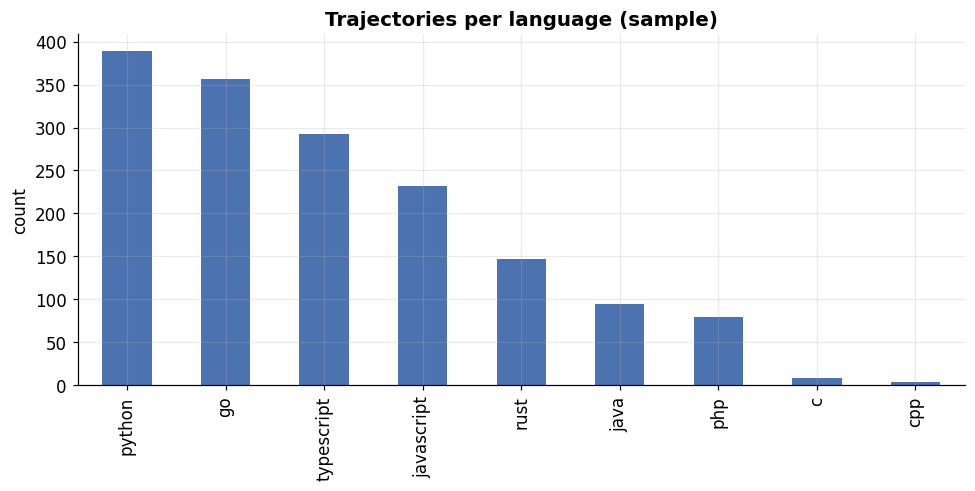


Resolution rate by language (n>=25):
              rate    n
language              
php         0.561   41
python      0.460  372
javascript  0.373  193
typescript  0.368  231
go          0.337  273
rust        0.304   92
java        0.246   61


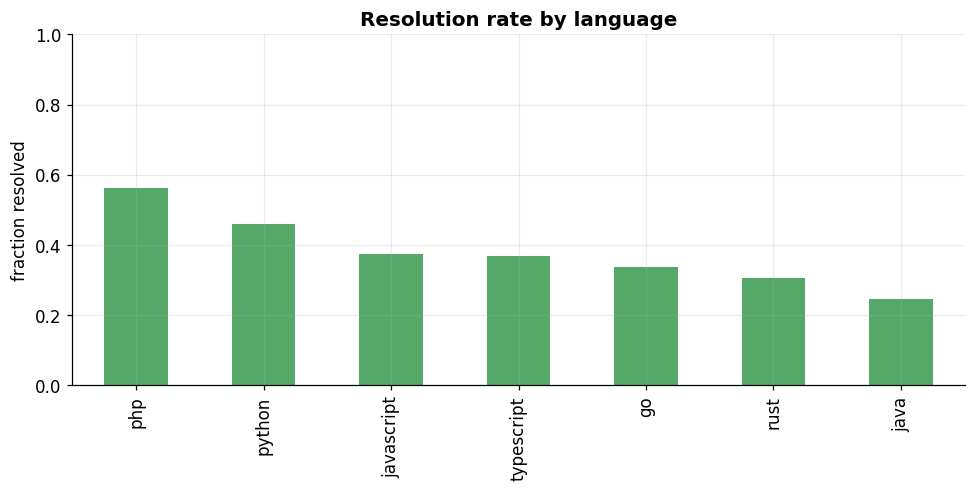


Resolution rate by scaffold x model:
 model      minimax_m25  qwen35_122b
agent                              
openhands        0.387        0.268
sweagent         0.460        0.421


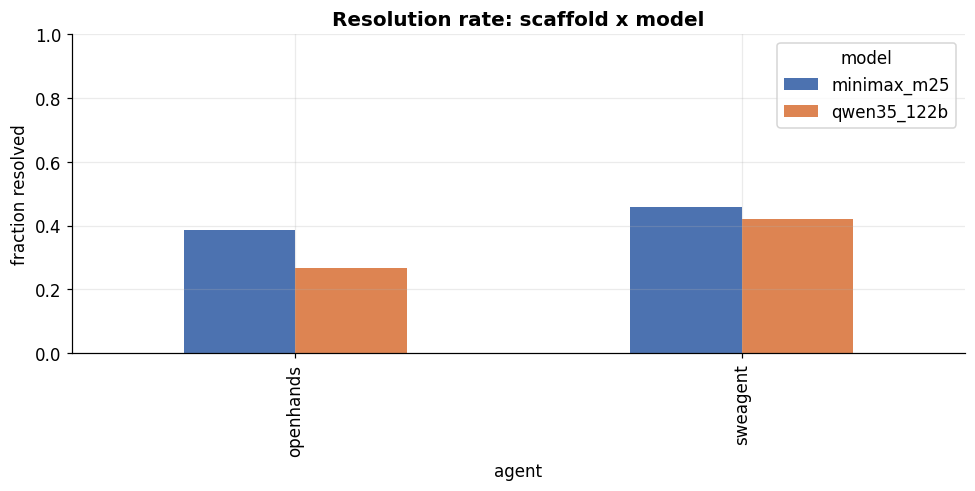

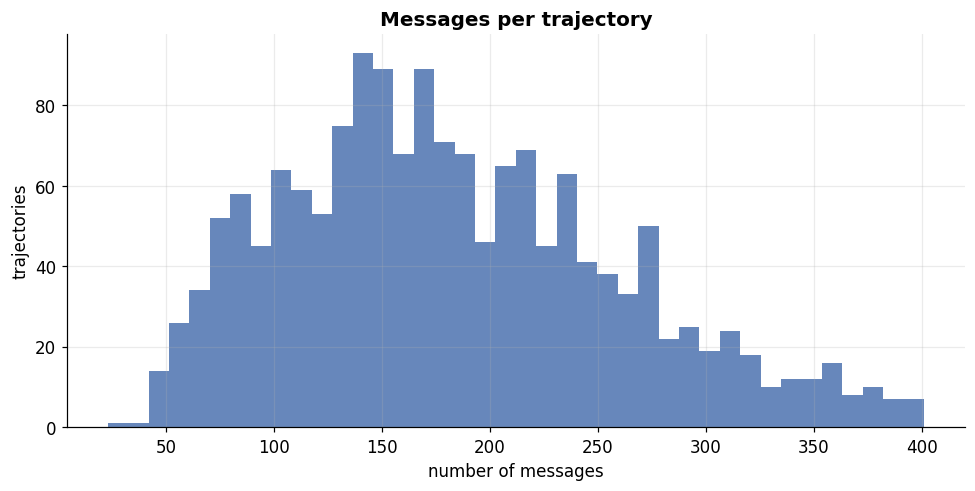

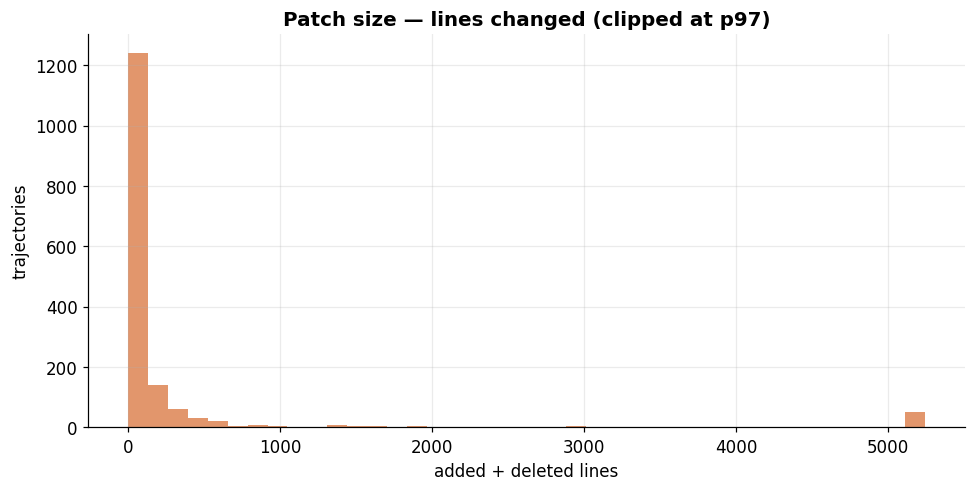

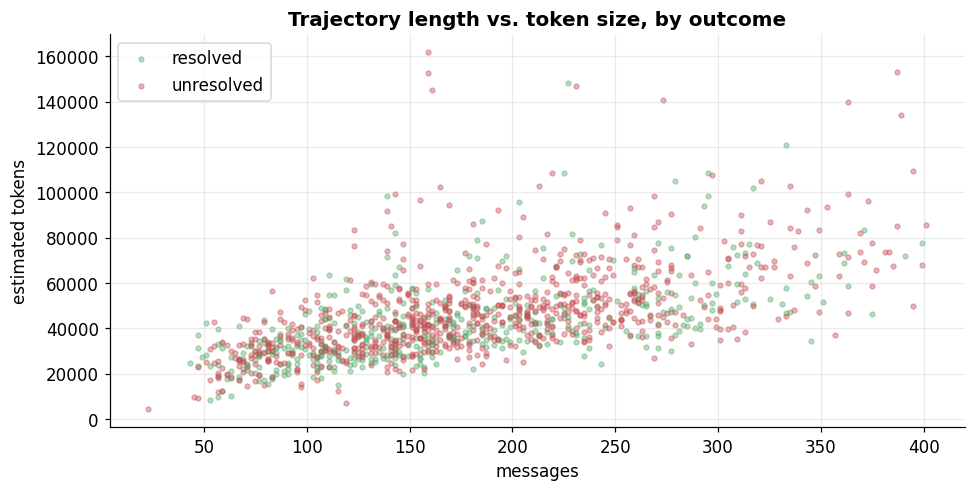


  STEP 5 — Token budget (what context window do you need?)
Estimated tokens per trajectory — percentiles:
  p50:   42,426
  p75:   53,722
  p90:   69,942
  p95:   80,518
  p99:  105,696
  max:  161,805

Fraction of trajectories that fit in a given context window:
    8,192 tokens :   0.1%
   16,384 tokens :   1.2%
   32,768 tokens :  24.0%
   65,536 tokens :  86.8%
  131,072 tokens :  99.4%


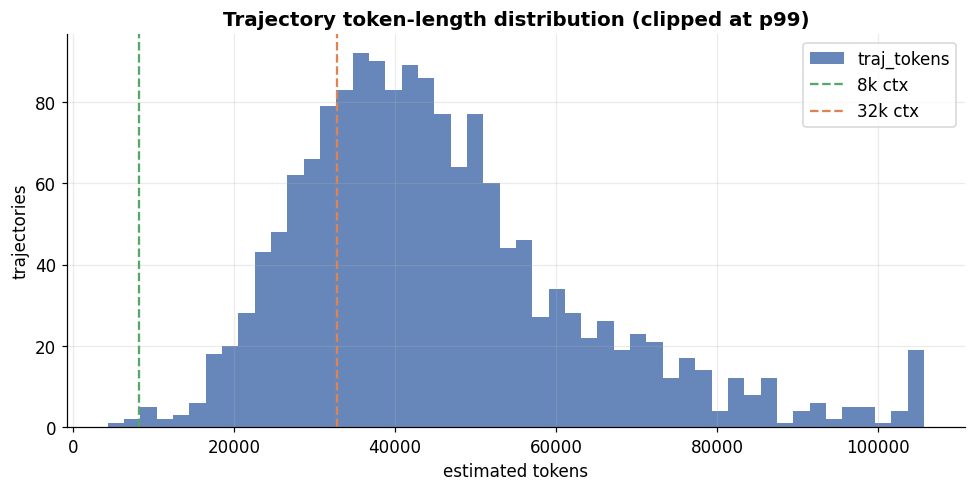


  STEP 6 — Which tools/actions do the agents use?
Most frequent agent actions (across the sample):
  bash                      60,597
  str_replace_editor        42,912
  execute_bash              37,633
  submit                     1,601
  think                      1,544
  finish                       800
  bash_block                     6
  view                           1


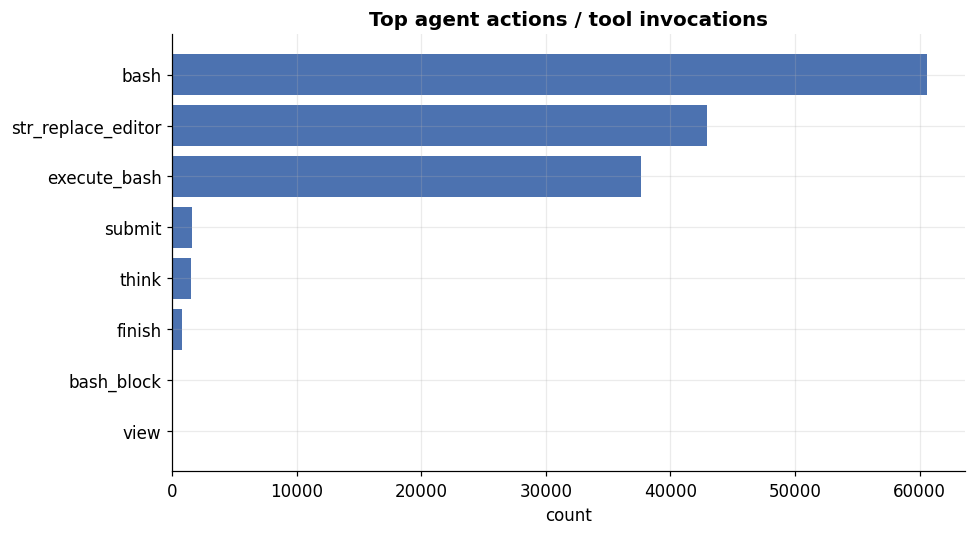


Mean 'tool' (environment) turns by outcome:
is_resolved
False    91.14
True     84.23

  STEP 7 — Building a curated SFT subset
Kept 149 / 1600 trajectories after filtering
  filters -> resolved_only=True, max_tokens=32,000, languages=all

Curated subset by language:
 language
python        67
typescript    22
javascript    21
go            19
php           10
rust           8
java           2

--- One formatted SFT example (ChatML, truncated) ---
<|im_start|>system
You are OpenHands agent, a helpful AI assistant that can interact with a computer to solve tasks.

<ROLE>
Your primary role is to assist users by executing commands, modifying code, and solving technical problems effectively. You should be thorough, methodical, and prioritize quality over speed.
* If the user asks a question, like "why is X happening", don't try to fix the problem. Just give an answer to the question.
</ROLE>

<EFFICIENCY>
* Each action you take is somewhat expensive. Wherever possible, combine multiple ac

In [1]:
banner("STEP 7 — Building a curated SFT subset")

def to_chatml(trajectory):
    out = []
    for m in trajectory:
        role = m.get("role", "unknown")
        out.append(f"<|im_start|>{role}\n{message_text(m).strip()}<|im_end|>")
    return "\n".join(out)

def passes_filters(rec, raw):
    if SFT_REQUIRE_RESOLVED and rec["resolved"] != 1:
        return False
    if rec["traj_tokens"] > MAX_SFT_TOKENS:
        return False
    if SFT_LANGUAGES is not None and rec["language"] not in SFT_LANGUAGES:
        return False
    if not (raw.get("model_patch") or "").strip():
        return False
    return True

sft_examples = []
for rec, raw in zip(records, raw_rows):
    if not passes_filters(rec, raw):
        continue
    messages = [{"role": m.get("role"), "content": message_text(m)}
                for m in normalize_trajectory(raw.get("trajectory"))]
    sft_examples.append({
        "instance_id": rec["instance_id"],
        "repo": rec["repo"],
        "language": rec["language"],
        "agent": rec["agent"],
        "model": rec["model"],
        "messages": messages,
        "text": to_chatml(messages),
        "model_patch": raw.get("model_patch"),
        "approx_tokens": rec["traj_tokens"],
    })

print(f"Kept {len(sft_examples)} / {len(records)} trajectories after filtering")
print(f"  filters -> resolved_only={SFT_REQUIRE_RESOLVED}, "
      f"max_tokens={MAX_SFT_TOKENS:,}, languages={SFT_LANGUAGES or 'all'}")
if sft_examples:
    kept = pd.DataFrame(sft_examples)
    print("\nCurated subset by language:\n", kept["language"].value_counts().to_string())
    print("\n--- One formatted SFT example (ChatML, truncated) ---")
    print(sft_examples[0]["text"][:600], "…")

banner("STEP 8 — Exporting artifacts")

csv_path = "open_swe_traces_analysis.csv"
df.drop(columns=["_tools"]).to_csv(csv_path, index=False)
print(f"  Wrote analysis table  -> {csv_path}  ({len(df)} rows)")

jsonl_path = "open_swe_sft.jsonl"
with open(jsonl_path, "w", encoding="utf-8") as f:
    for ex in sft_examples:
        f.write(json.dumps(ex, ensure_ascii=False) + "\n")
print(f"  Wrote SFT dataset     -> {jsonl_path}  ({len(sft_examples)} rows)")

print("\nDone. In Colab, open the Files pane (folder icon, left) to download both.")
print("To load the SFT file later:  datasets.load_dataset('json', "
      "data_files='open_swe_sft.jsonl')")